In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from pathlib import Path


ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_smoking_cleaned.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

# 自動建立輸出資料夾
for path in [FIG_DIR, TAB_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# 設定繪圖風格
sns.set_theme(style="whitegrid")

# 2. 讀取資料與標籤對閱
df = pd.read_csv(PROCESSED_PATH)

# 將數值對應到文字標籤，方便後續報表與畫圖閱讀
df['Sex_Label'] = df['WhatIsYourSex'].map({1.0: 'Female', 2.0: 'Male'})

In [2]:
# 3. 敘述性統計：次數與比例分配表
print("=== [STEP 1] 男女抽菸人數與比例交叉摘要 ===")
# 產生次數分配表（含 Total 總計）
crosstab_counts = pd.crosstab(df['Sex_Label'], df['Smoking_Status'], margins=True, margins_name="Total")
# 產生比例分配表
crosstab_props = pd.crosstab(df['Sex_Label'], df['Smoking_Status'], normalize='index')

print("\n[次數分配表]")
display(crosstab_counts)
print("\n[比例分配表]")
display(crosstab_props.style.format("{:.2%}"))

# 4. 核心雙樣本推論：Two-proportion Z-test & CI
print("\n=== [STEP 2] 雙樣本比例 Z 檢定與信賴區間計算 ===")
group_stats = df.groupby('Sex_Label')['Smoking_Status'].agg(['sum', 'count'])

n_male = group_stats.loc['Male', 'count']
s_male = group_stats.loc['Male', 'sum']
n_female = group_stats.loc['Female', 'count']
s_female = group_stats.loc['Female', 'sum']

p_male = s_male / n_male
p_female = s_female / n_female
obs_diff = p_male - p_female

# 執行 Two-proportion z-test
count = [s_male, s_female]
nobs = [n_male, n_female]
z_stat, p_val = proportions_ztest(count, nobs)

# 計算兩組比例差異的 95% 信賴區間
ci_low, ci_upp = confint_proportions_2indep(s_male, n_male, s_female, n_female, method='wald')

print(f"觀測到的比例差異 (Male - Female): {obs_diff:.4f}")
print(f"Z 檢定統計量 (Z-statistic): {z_stat:.4f}")
print(f"P 值 (P-value): {p_val:.4e}")
print(f"差異的 95% 信賴區間: [{ci_low:.4f}, {ci_upp:.4f}]")

# 建立並儲存摘要表 (Summary Table)
summary_table = pd.DataFrame({
    'Metric': ['Sample Size (n)', 'Smokers (count)', 'Proportion (p-hat)'],
    'Male': [n_male, s_male, f"{p_male:.2%}"],
    'Female': [n_female, s_female, f"{p_female:.2%}"]
})
summary_table.to_csv(TAB_DIR / "01_smoking_inference_summary.csv", index=False)
print("\n[已儲存推論摘要表至 tables 資料夾]")
display(summary_table)

=== [STEP 1] 男女抽菸人數與比例交叉摘要 ===

[次數分配表]


Smoking_Status,0,1,Total
Sex_Label,,,
Female,5452,1153,6605
Male,5015,1405,6420
Total,10467,2558,13025



[比例分配表]


Smoking_Status,0,1
Sex_Label,,
Female,82.54%,17.46%
Male,78.12%,21.88%



=== [STEP 2] 雙樣本比例 Z 檢定與信賴區間計算 ===
觀測到的比例差異 (Male - Female): 0.0443
Z 檢定統計量 (Z-statistic): 6.3601
P 值 (P-value): 2.0161e-10
差異的 95% 信賴區間: [0.0306, 0.0579]

[已儲存推論摘要表至 tables 資料夾]


,Metric,Male,Female
0,Sample Size (n),6420,6605
1,Smokers (count),1405,1153
2,Proportion (p-hat),21.88%,17.46%



=== [STEP 3] 繪製並儲存視覺化圖表 ===


C:\Users\user\AppData\Local\Temp\ipykernel_13648\3932965853.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax1 = sns.barplot(x='Sex_Label', y='Smoking_Status', data=df, ci=None, palette='pastel')
C:\Users\user\AppData\Local\Temp\ipykernel_13648\3932965853.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Sex_Label', y='Smoking_Status', data=df, ci=None, palette='pastel')


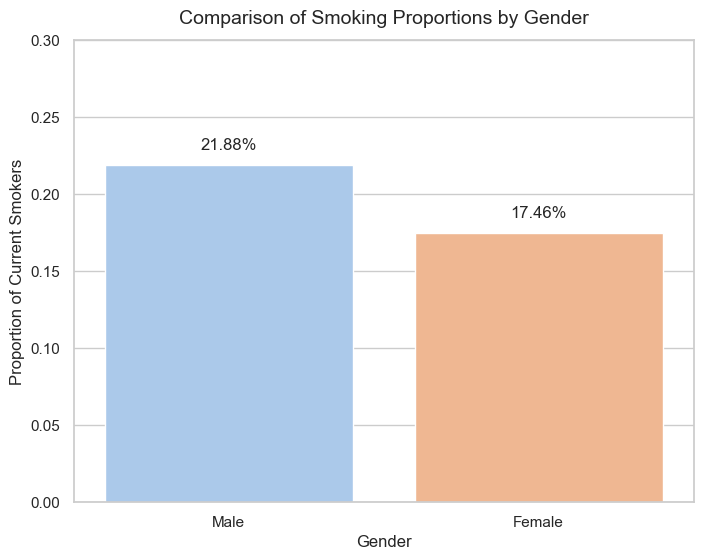

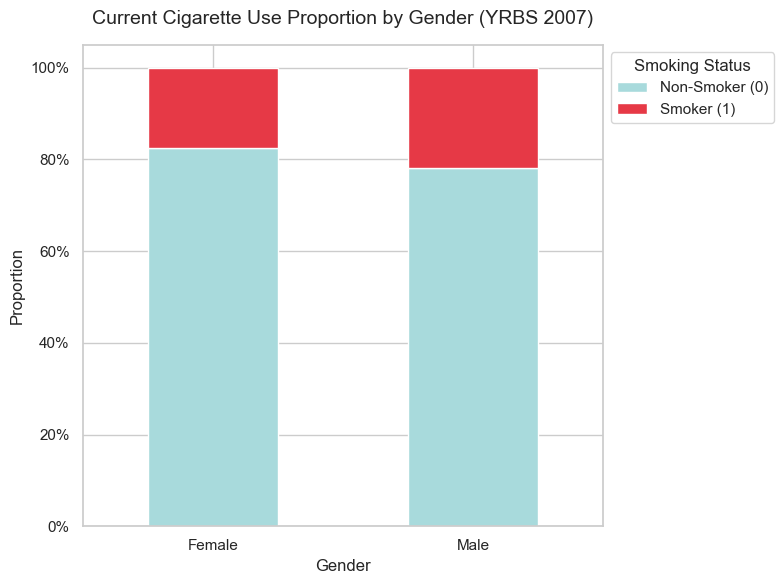

In [5]:
# 5. 資料視覺化
print("\n=== [STEP 3] 繪製並儲存視覺化圖表 ===")

# 圖 1: 男女抽菸比例長條圖
plt.figure(figsize=(8, 6))
ax1 = sns.barplot(x='Sex_Label', y='Smoking_Status', data=df, ci=None, palette='pastel')
plt.title('Comparison of Smoking Proportions by Gender', fontsize=14, pad=12)
plt.ylabel('Proportion of Current Smokers')
plt.xlabel('Gender')
plt.ylim(0, 0.3)

# 在長條圖上方標註精確百分比
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', fontsize=12)

plt.savefig(FIG_DIR / "01_proportion_barplot.png", dpi=100)
plt.show()


# 圖 2: 100% 堆疊長條圖
fig, ax2 = plt.subplots(figsize=(8, 6))
crosstab_props.plot(kind='bar', stacked=True, color=['#A8DADC', '#E63946'], width=0.5, ax=ax2)
plt.title('Current Cigarette Use Proportion by Gender (YRBS 2007)', fontsize=14, pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Smoking Status', labels=['Non-Smoker (0)', 'Smoker (1)'], bbox_to_anchor=(1, 1))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig(FIG_DIR / "02_proportion_per_group_barplot.png", dpi=100)
plt.show()



C:\Users\user\AppData\Local\Temp\ipykernel_13648\179116579.py:44: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13648\179116579.py:47: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / "03_difference_ci_plot.png", dpi=120)


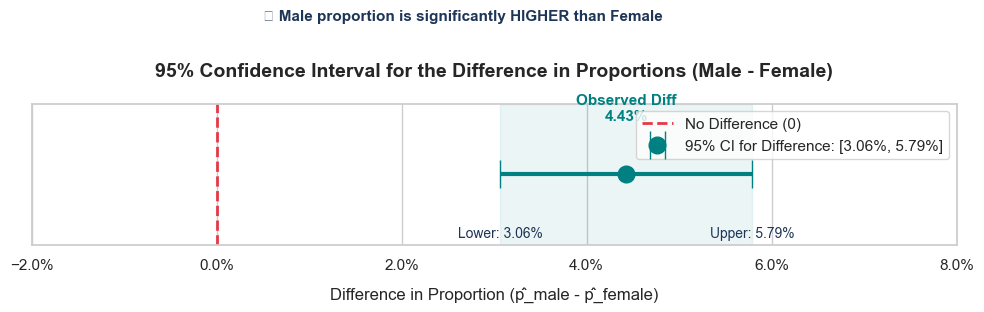

In [7]:
plt.figure(figsize=(10, 4.5))

# 1. 繪製信賴區間主體 (修正後：統一使用 :.2% 格式化輸出)
plt.errorbar(obs_diff, 0, xerr=[[obs_diff - ci_low], [ci_upp - obs_diff]], 
             fmt='o', markersize=12, capsize=10, color='teal', elinewidth=3,
             label=f'95% CI for Difference: [{ci_low:.2%}, {ci_upp:.2%}]')

# 2. 繪製虛無假設紅線 (0)
plt.axvline(x=0, color='#E63946', linestyle='--', linewidth=2, label='No Difference (0)')

# 3. 在圖上標註精確的數字（Data Labels）
# 標註觀測差異值 (Point Estimate)
plt.text(obs_diff, 0.04, f"Observed Diff\n{obs_diff:.2%}", 
         ha='center', va='bottom', color='teal', weight='bold', fontsize=11)

# 標註信賴區間下界 (Lower Bound)
plt.text(ci_low, -0.04, f"Lower: {ci_low:.2%}", 
         ha='center', va='top', color='#1D3557', fontsize=10)

# 標註信賴區間上界 (Upper Bound)
plt.text(ci_upp, -0.04, f"Upper: {ci_upp:.2%}", 
         ha='center', va='top', color='#1D3557', fontsize=10)

# 4. 加上統計結論的區間文字說明與陰影引導
# 著色顯著區域（從下界到上界）
plt.axvspan(ci_low, ci_upp, color='teal', alpha=0.08)

# 加上情境解讀文字
plt.text(0.005, 0.12, "⭐ Male proportion is significantly HIGHER than Female", 
         fontsize=11, color='#1D3557', weight='bold', ha='left')

# 5. 美化圖表細節
plt.title('95% Confidence Interval for the Difference in Proportions (Male - Female)', 
          fontsize=14, pad=20, weight='bold')
plt.xlabel('Difference in Proportion (p̂_male - p̂_female)', fontsize=12, labelpad=10)

# 調整 X 軸刻度格式為百分比
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xlim(-0.02, 0.08) # 調整左右留白，讓 0 點和區間的位置比例最漂亮
plt.yticks([])        # 隱藏無意義的 Y 軸
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

# 儲存優化後的圖片
plt.savefig(FIG_DIR / "03_difference_ci_plot.png", dpi=120)
plt.show()